# Cuaderno De Análisis Exploratorio De Datos (EDA) Avanzado: Criptomonedas y Stablecoins

## Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

## Configuración Entorno

In [2]:
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

## Carga y Preprocesamiento de los Datasets

In [3]:
print("=== Cargando datasets clean...")

df_crypto = pd.read_csv("../data/clean/criptoradar_crypto_final_clean.csv")
df_stable = pd.read_csv("../data/clean/datos_preprocesados_clean.csv")

# Ingeniería de variables rápidas
df_crypto['daily_volatility_pct'] = (df_crypto['high'] - df_crypto['low']) / df_crypto['open'] * 100
df_crypto['returns_pct'] = df_crypto.groupby('crypto_id')['close'].pct_change() * 100

print(f"Dataset Cripto: {df_crypto.shape[0]} filas | Columnas: {list(df_crypto.columns)}")
print(f"Dataset Stablecoins: {df_stable.shape[0]} filas | Columnas: {list(df_stable.columns)}")

=== Cargando datasets clean...
Dataset Cripto: 3200 filas | Columnas: ['crypto_id', 'open', 'high', 'low', 'close', 'volume', 'datetime', 'daily_volatility_pct', 'returns_pct']
Dataset Stablecoins: 15021 filas | Columnas: ['datetime', 'market_cap', 'price', 'peg_deviation', 'supply_change_1d', 'supply_change_7d', 'price_volatility_3d', 'stablecoin', 'stablecoin_id']


## Relación de fluctuación asimétrica y desviación como Anomalía


Distribución de Volatilidad vs Desviación del Peg...


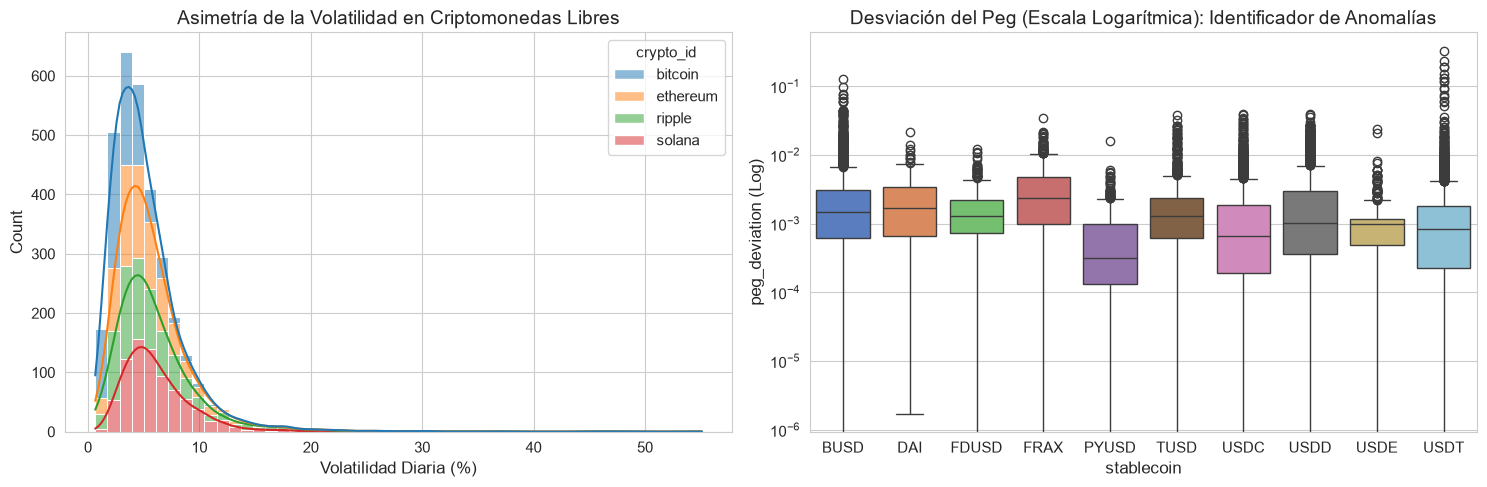

In [4]:
print("\nDistribución de Volatilidad vs Desviación del Peg...")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=df_crypto, x='daily_volatility_pct', hue='crypto_id', kde=True, ax=axes[0], bins=50, multiple="stack")
axes[0].set_title('Asimetría de la Volatilidad en Criptomonedas Libres')
axes[0].set_xlabel('Volatilidad Diaria (%)')

sns.boxplot(data=df_stable, x='stablecoin', y='peg_deviation', ax=axes[1], palette="muted")
axes[1].set_yscale('log')
axes[1].set_title('Desviación del Peg (Escala Logarítmica): Identificador de Anomalías')
axes[1].set_ylabel('peg_deviation (Log)')
plt.tight_layout()
plt.show()

## StableCoins Más/Menos Estables y Efecto del Market CAP


Análisis de Estabilidad y Tamaño de Suministro Circulante...

--- Tabla de Estabilidad Comparativa por Stablecoin ---
            desviacion_promedio  desviacion_maxima  volatilidad_prom_3d  market_cap_promedio
stablecoin                                                                                  
PYUSD                  0.000678           0.016000             0.000575         8.415356e+06
USDE                   0.001099           0.024000             0.000640         4.584598e+07
FDUSD                  0.001617           0.012359             0.001169         4.817211e+09
USDC                   0.001737           0.039867             0.001258         2.862608e+10
TUSD                   0.002034           0.038488             0.001272         6.804864e+08
DAI                    0.002296           0.021845             0.001867         5.240181e+09
USDT                   0.002354           0.328150             0.001766         6.477324e+10
USDD                   0.003130           0.

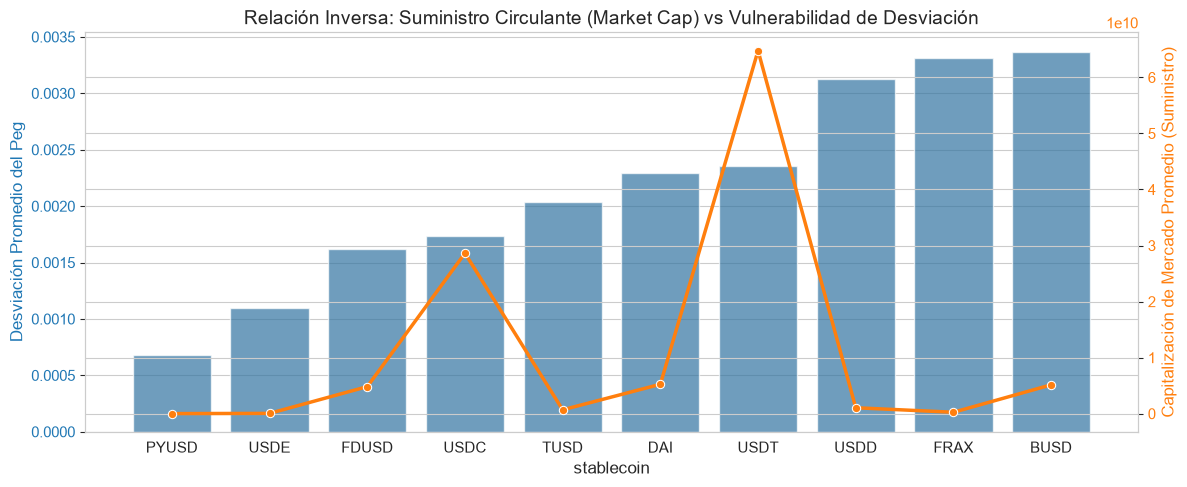

In [5]:
print("\nAnálisis de Estabilidad y Tamaño de Suministro Circulante...")

estabilidad_resumen = df_stable.groupby('stablecoin').agg(
    desviacion_promedio=('peg_deviation', 'mean'),
    desviacion_maxima=('peg_deviation', 'max'),
    volatilidad_prom_3d=('price_volatility_3d', 'mean'),
    market_cap_promedio=('market_cap', 'mean')
).sort_values(by='desviacion_promedio')

print("\n--- Tabla de Estabilidad Comparativa por Stablecoin ---")
print(estabilidad_resumen.to_string())

fig, ax1 = plt.subplots(figsize=(12, 5))
color = 'tab:blue'
sns.barplot(data=estabilidad_resumen.reset_index(), x='stablecoin', y='desviacion_promedio', ax=ax1, color=color, alpha=0.7)
ax1.set_ylabel('Desviación Promedio del Peg', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:orange'
sns.lineplot(data=estabilidad_resumen.reset_index(), x='stablecoin', y='market_cap_promedio', ax=ax2, color=color, marker='o', linewidth=2.5)
ax2.set_ylabel('Capitalización de Mercado Promedio (Suministro)', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Relación Inversa: Suministro Circulante (Market Cap) vs Vulnerabilidad de Desviación')
plt.tight_layout()
plt.show()

## Correlación de precios Criptomonedas y el efecto de la liquidez (Volumen)


Correlación Cruzada y Efecto del Volumen sobre el Precio...


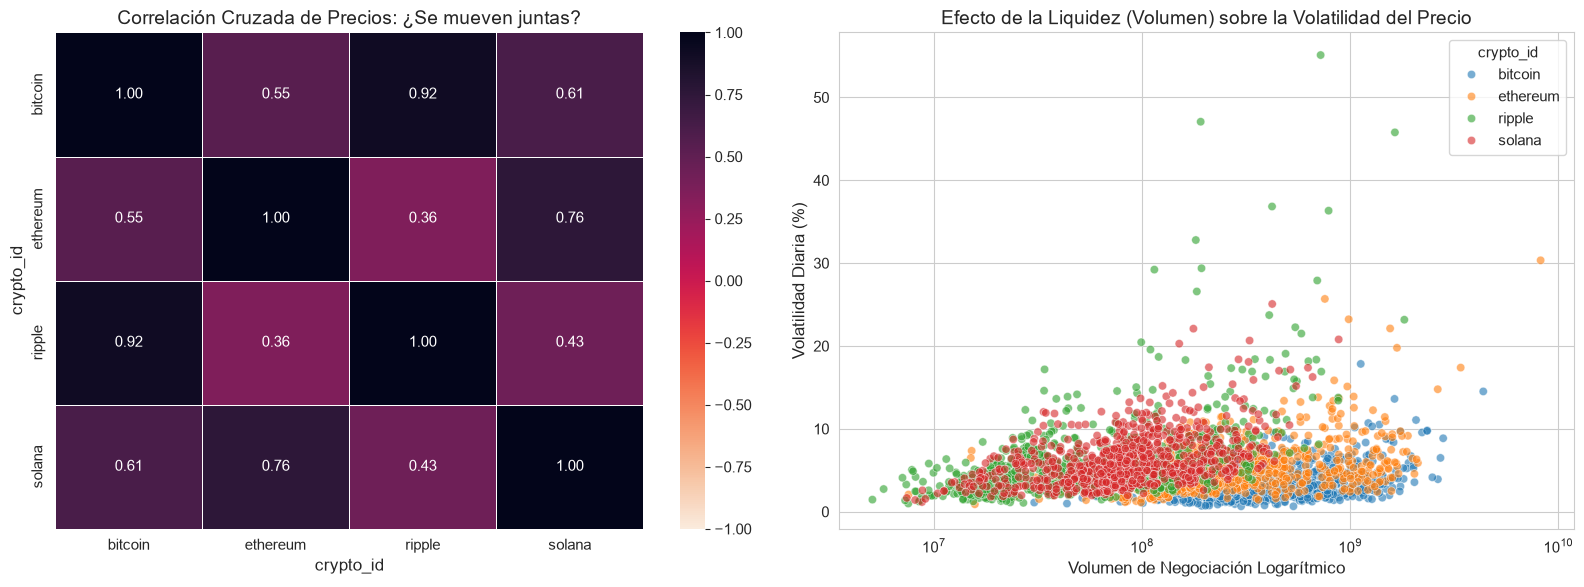

In [6]:
print("\nCorrelación Cruzada y Efecto del Volumen sobre el Precio...")

# Pivotar datos para matriz de correlación cruzada
df_pivot_prices = df_crypto.pivot(index='datetime', columns='crypto_id', values='close').dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(df_pivot_prices.corr(method='pearson'), annot=True, cmap='rocket_r', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlación Cruzada de Precios: ¿Se mueven juntas?')

sns.scatterplot(data=df_crypto, x='volume', y='daily_volatility_pct', hue='crypto_id', alpha=0.6, ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_title('Efecto de la Liquidez (Volumen) sobre la Volatilidad del Precio')
axes[1].set_xlabel('Volumen de Negociación Logarítmico')
axes[1].set_ylabel('Volatilidad Diaria (%)')
plt.tight_layout()
plt.show()

## Impacto de Bitcoin/Ethereum en las StableCoins (Análisis Cruzado)

**Nota importante antes de cruzar:** antes de mergear por fecha, primero comprobamos que
los periodos de ambos datasets realmente se solapen. Si no se solapan, un `inner merge`
devuelve 0 filas para esa moneda (no es un error de código, es un límite de los datos).


In [7]:
print("\nAnálisis de Interdependencia Temporal Cripto-Stablecoins...")

# Asegurar formato de fecha como texto para el cruce limpio
df_crypto['datetime_clean'] = pd.to_datetime(df_crypto['datetime']).dt.strftime('%Y-%m-%d')
df_stable['datetime_clean'] = pd.to_datetime(df_stable['datetime']).dt.strftime('%Y-%m-%d')

# Filtrar Bitcoin usando minúsculas para prevenir discrepancias ('bitcoin' o 'BTC')
df_btc = df_crypto[df_crypto['crypto_id'].astype(str).str.lower().isin(['bitcoin', 'btc'])][['datetime_clean', 'daily_volatility_pct', 'close']].rename(
    columns={'daily_volatility_pct': 'btc_volatility', 'close': 'btc_price'}
)

# Filtrar Ethereum usando ambos formatos habituales ('ethereum' o 'eth')
df_eth = df_crypto[df_crypto['crypto_id'].astype(str).str.lower().isin(['ethereum', 'eth'])][['datetime_clean', 'daily_volatility_pct', 'close']].rename(
    columns={'daily_volatility_pct': 'eth_volatility', 'close': 'eth_price'}
)

# Construcción del DataFrame unificado mediante Cruce Interno (Inner Merge)
df_cruzado = df_stable.merge(df_btc, on='datetime_clean', how='inner').merge(df_eth, on='datetime_clean', how='inner')

# Filtrar DAI eliminando espacios y forzando coincidencia exacta
df_cruzado['stablecoin'] = df_cruzado['stablecoin'].astype(str).str.strip().str.upper()
df_dai = df_cruzado[df_cruzado['stablecoin'] == 'DAI']

print(f"Filas Totales en df_cruzado: {df_cruzado.shape[0]}")
print(f"Filas específicas encontradas para DAI: {df_dai.shape[0]}")

# --- DIAGNÓSTICO: por qué puede quedar vacío df_dai (no es un problema de nombres/espacios) ---
# Comparamos el rango de fechas de DAI en bruto contra el rango de fechas del dataset cripto.
dai_raw = df_stable[df_stable['stablecoin'].astype(str).str.strip().str.upper() == 'DAI']
print(f"\nRango de fechas de DAI en el dataset de stablecoins: {dai_raw['datetime_clean'].min()} -> {dai_raw['datetime_clean'].max()} ({len(dai_raw)} filas)")
print(f"Rango de fechas del dataset de criptomonedas (BTC/ETH): {df_crypto['datetime_clean'].min()} -> {df_crypto['datetime_clean'].max()}")
print("\n(Si estos dos rangos no se solapan, el merge por fecha para DAI siempre dará 0 filas,")
print(" sin importar cómo se limpien nombres, espacios o mayúsculas)")



Análisis de Interdependencia Temporal Cripto-Stablecoins...
Filas Totales en df_cruzado: 6062
Filas específicas encontradas para DAI: 0

Rango de fechas de DAI en el dataset de stablecoins: 2020-12-03 -> 2022-05-11 (500 filas)
Rango de fechas del dataset de criptomonedas (BTC/ETH): 2024-04-27 -> 2026-07-08

(Si estos dos rangos no se solapan, el merge por fecha para DAI siempre dará 0 filas,
 sin importar cómo se limpien nombres, espacios o mayúsculas)


❌ DAI no tiene NINGÚN día en común con el dataset de criptomonedas.
   DAI termina en 2022-05-11 y el dataset cripto empieza en 2024-04-27.
   Esto es una limitación de los datos, no un bug de nombres/formato: no existe forma de
   correlacionar la volatilidad de ETH con el peg de DAI sin ampliar alguno de los dos históricos.
   Como alternativa, mostramos abajo el comportamiento propio de DAI en su propio periodo disponible.


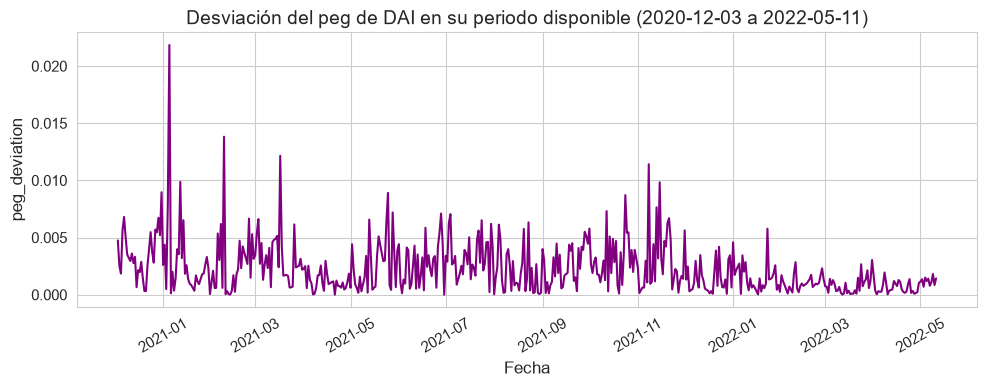

In [8]:
if df_dai.shape[0] == 0:
    # Confirmamos la causa real: ¿hay overlap de fechas entre DAI y el dataset cripto?
    solapan = (dai_raw['datetime_clean'].max() >= df_crypto['datetime_clean'].min()) and \
              (dai_raw['datetime_clean'].min() <= df_crypto['datetime_clean'].max())

    if not solapan:
        print("❌ DAI no tiene NINGÚN día en común con el dataset de criptomonedas.")
        print(f"   DAI termina en {dai_raw['datetime_clean'].max()} y el dataset cripto empieza en {df_crypto['datetime_clean'].min()}.")
        print("   Esto es una limitación de los datos, no un bug de nombres/formato: no existe forma de")
        print("   correlacionar la volatilidad de ETH con el peg de DAI sin ampliar alguno de los dos históricos.")
        print("   Como alternativa, mostramos abajo el comportamiento propio de DAI en su propio periodo disponible.")

        # --- Análisis alternativo autocontenido: volatilidad del peg de DAI en su propio periodo ---
        fig, ax = plt.subplots(figsize=(10, 4))
        dai_raw_sorted = dai_raw.sort_values('datetime_clean')
        ax.plot(pd.to_datetime(dai_raw_sorted['datetime_clean']), dai_raw_sorted['peg_deviation'], color='purple')
        ax.set_title(f"Desviación del peg de DAI en su periodo disponible ({dai_raw['datetime_clean'].min()} a {dai_raw['datetime_clean'].max()})")
        ax.set_xlabel('Fecha')
        ax.set_ylabel('peg_deviation')
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()
    else:
        # Si en el futuro los datos se actualizan y sí solapan pero sigue dando 0 filas,
        # entonces sí sería un problema de nombres/formato -> lo mostramos aquí
        print(f"⚠️ ALERTA: 'df_dai' sigue vacío pese a haber solape de fechas. Nombres disponibles en 'stablecoin': {df_cruzado['stablecoin'].unique()}")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Gráfico 1: Impacto del Bitcoin en el Mercado General de Stablecoins
    sns.regplot(data=df_cruzado, x='btc_volatility', y='peg_deviation',
                scatter_kws={'alpha':0.4, 'color':'gray'}, line_kws={'color':'red', 'linewidth':2}, ax=axes[0])
    axes[0].set_title('Impacto Global: Volatilidad de BTC vs Desviación de Stablecoins')
    axes[0].set_xlabel('Volatilidad Diaria de Bitcoin (%)')
    axes[0].set_ylabel('Desviación del Peg General')

    # Gráfico 2: Impacto del Colateral (Ethereum) sobre DAI
    sns.regplot(data=df_dai, x='eth_volatility', y='peg_deviation',
                scatter_kws={'alpha':0.6, 'color':'purple'}, line_kws={'color':'darkblue', 'linewidth':2}, ax=axes[1])
    axes[1].set_title('Relación Estructural Directa: Volatilidad de ETH vs Peg de DAI')
    axes[1].set_xlabel('Volatilidad Diaria de Ethereum (%)')
    axes[1].set_ylabel('Desviación del Peg (DAI)')

    plt.tight_layout()
    plt.show()


In [9]:
# NOTA: df_cruzado no incluye a DAI (no comparte fechas con el dataset cripto),
# por lo que esta matriz refleja únicamente las 9 stablecoins restantes.
# Mostrar matriz de correlaciones numéricas del dataset unificado
print("\n--- Matriz de Correlación Cruzada entre Estructuras de Mercado ---")
columnas_interes = ['peg_deviation', 'price_volatility_3d', 'market_cap', 'btc_volatility', 'eth_volatility']
print(df_cruzado[columnas_interes].corr().round(3))


--- Matriz de Correlación Cruzada entre Estructuras de Mercado ---
                     peg_deviation  price_volatility_3d  market_cap  \
peg_deviation                1.000                0.594      -0.159   
price_volatility_3d          0.594                1.000      -0.129   
market_cap                  -0.159               -0.129       1.000   
btc_volatility               0.032                0.002      -0.011   
eth_volatility               0.019                0.009      -0.003   

                     btc_volatility  eth_volatility  
peg_deviation                 0.032           0.019  
price_volatility_3d           0.002           0.009  
market_cap                   -0.011          -0.003  
btc_volatility                1.000           0.739  
eth_volatility                0.739           1.000  
